# Bank Fraud Transaction Analysis(Cleaning and EDA)
**Dataset:** Indian Banking Transactions(2019-2024)  
**Objective:** Understand transaction patterns, detect behavioural signals of fraud, and surface actionable insights through structured exploratory data analysis.

---

In [4]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

In [5]:
# Lets see what's in the data
# Using os.path keeps this portable across machines.
DATA_PATH = os.path.join(r"C:\Users\jahnv\Downloads\bank eda\indian_banking_transactions.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,transaction_id,customer_id,transaction_date,transaction_time,account_type,transaction_type,transaction_amount,transaction_direction,account_balance,merchant_category,state,credit_score,has_loan,loan_type,emi_amount,transaction_status,channel,kyc_status,is_fraud,transaction_hour
0,TXN000000001,CUST015796,2019-01-01,15:28,Current,UPI,1820.17,Debit,609365.31,Food & Dining,Maharashtra,764,0,NaN,0.00,Success,Branch,Verified,0,15
1,TXN000000002,CUST000861,2019-01-01,03:00,Current,UPI,392.67,Credit,14451.14,Education,West Bengal,630,0,NaN,0.00,Success,Mobile_App,Verified,0,3
2,TXN000000003,CUST076821,2019-01-01,18:03,Fixed Deposit,POS,1255.97,Debit,47621.87,Utilities,Punjab,813,1,Home,1433.91,Success,Mobile_App,Verified,0,18
3,TXN000000004,CUST054887,2019-01-01,08:03,Savings,UPI,2580.68,Debit,34467.85,Travel,Karnataka,628,1,Personal,6280.35,Success,API,Verified,0,8
4,TXN000000005,CUST006266,2019-01-01,14:23,Fixed Deposit,UPI,2573.80,Debit,26617.40,Utilities,West Bengal,767,0,NaN,0.00,Success,API,Verified,0,14


### Description

| Feature | Type | Description |
|---|---|---|
| transaction_id | Categorical | Unique transaction identifier |
| customer_id | Categorical | Unique customer identifier |
| transaction_date | Datetime | Date of transaction |
| transaction_time | Time | Time of transaction |
| account_type | Categorical | Savings / Current |
| transaction_type | Categorical | UPI, IMPS, NEFT, RTGS, Debit Card, ATM, Net Banking, Credit Card |
| transaction_amount | Continuous | Monetary value (INR) |
| transaction_direction | Categorical | Credit / Debit |
| account_balance | Continuous | Balance after transaction |
| merchant_category | Categorical | Grocery, Fuel, Shopping, Healthcare, Entertainment, etc. |
| state | Categorical | Indian state of transaction |
| credit_score | Numerical | Customer creditworthiness score |
| has_loan | Categorical | Active loan: Yes / No |
| loan_type | Categorical | Home, Personal, Vehicle, Education, No Loan |
| emi_amount | Continuous | Monthly EMI (0 for customers without loans) |
| transaction_status | Categorical | Success / Failed / Pending |
| channel | Categorical | Mobile Banking, Internet Banking, ATM, Branch, POS |
| kyc_status | Categorical | Verified / Pending |
| is_fraud | Binary (Target) | 0 = Genuine, 1 = Fraudulent |
| transaction_hour | Numerical | Hour of day (0–23) |

### Data Cleaning

In [6]:
# a quick shape and basic info
print("Shape:", df.shape)
df.info()

Shape: (550000, 20)
<class 'pandas.DataFrame'>
RangeIndex: 550000 entries, 0 to 549999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   transaction_id         550000 non-null  str    
 1   customer_id            550000 non-null  str    
 2   transaction_date       550000 non-null  str    
 3   transaction_time       550000 non-null  str    
 4   account_type           550000 non-null  str    
 5   transaction_type       550000 non-null  str    
 6   transaction_amount     550000 non-null  float64
 7   transaction_direction  550000 non-null  str    
 8   account_balance        550000 non-null  float64
 9   merchant_category      550000 non-null  str    
 10  state                  550000 non-null  str    
 11  credit_score           550000 non-null  int64  
 12  has_loan               550000 non-null  int64  
 13  loan_type              172866 non-null  str    
 14  emi_amount             5500

In [7]:
# Stastical Description of Data
df.describe()

,transaction_amount,account_balance,credit_score,has_loan,emi_amount,is_fraud,transaction_hour
count,5.500000e+05,5.500000e+05,550000.000000,550000.000000,550000.000000,550000.00000,550000.000000
mean,2.990709e+04,8.455012e+04,599.807009,0.349615,2365.859974,0.00886,11.504431
std,1.396101e+05,1.709146e+05,173.054597,0.476849,4973.546080,0.09371,6.924499
min,2.400000e+00,5.000000e+02,300.000000,0.000000,0.000000,0.00000,0.000000
25%,7.630375e+02,1.515778e+04,450.000000,0.000000,0.000000,0.00000,6.000000
50%,2.035735e+03,3.642287e+04,600.000000,0.000000,0.000000,0.00000,11.000000
75%,8.557497e+03,8.760704e+04,750.000000,1.000000,3115.030000,0.00000,17.000000
max,1.000000e+07,5.000000e+06,899.000000,1.000000,153325.740000,1.00000,23.000000


In [8]:
# Null check
print("Null counts:\n", df.isnull().sum())

Null counts:
 transaction_id                0
customer_id                   0
transaction_date              0
transaction_time              0
account_type                  0
transaction_type              0
transaction_amount            0
transaction_direction         0
account_balance               0
merchant_category             0
state                         0
credit_score                  0
has_loan                      0
loan_type                377134
emi_amount                    0
transaction_status            0
channel                       0
kyc_status                    0
is_fraud                      0
transaction_hour              0
dtype: int64


In [9]:
# Unique value checks
for col in ['transaction_type', 'transaction_direction', 'merchant_category', 'loan_type']:
    print(f"{col}: {df[col].unique()}")

transaction_type: <StringArray>
[           'UPI',            'POS',    'Net_Banking',           'NEFT',
    'Credit_Card',         'Cheque', 'ATM_Withdrawal',           'IMPS',
           'RTGS',     'Auto_Debit']
Length: 10, dtype: str
transaction_direction: <StringArray>
['Debit', 'Credit']
Length: 2, dtype: str
merchant_category: <StringArray>
['Food & Dining',     'Education',     'Utilities',        'Travel',
    'Government',    'Investment',    'Healthcare',   'Real Estate',
    'E-Commerce',        'Retail',          'Fuel',        'Salary',
 'Entertainment', 'Peer Transfer',     'Insurance']
Length: 15, dtype: str
loan_type: <StringArray>
[nan, 'Home', 'Personal', 'Auto', 'Gold', 'Education', 'Business']
Length: 7, dtype: str


In [10]:
# Target variable distribution
print("Fraud value counts:\n", df['is_fraud'].value_counts())
print("\nFraud rate: {:.2f}%".format(df['is_fraud'].mean() * 100))

Fraud value counts:
 is_fraud
0    545127
1      4873
Name: count, dtype: int64

Fraud rate: 0.89%


In [11]:
# Date parsing and feature engineering
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

df["year"]       = df["transaction_date"].dt.year
df["month"]      = df["transaction_date"].dt.month
df["month_name"] = df["transaction_date"].dt.strftime("%b")
df["day"]        = df["transaction_date"].dt.day
df["day_name"]   = df["transaction_date"].dt.day_name()
df["quarter"]    = df["transaction_date"].dt.quarter
df["year_month"] = df["transaction_date"].dt.to_period("M").astype(str)

print("Date features created:", ["year","month","month_name","day","day_name","quarter","year_month"])

Date features created: ['year', 'month', 'month_name', 'day', 'day_name', 'quarter', 'year_month']


In [12]:
# Fill nulls with domain-appropriate values
df["merchant_category"] = df["merchant_category"].fillna("Unknown")
df["loan_type"]         = df["loan_type"].fillna("No Loan")
df["emi_amount"]        = df["emi_amount"].fillna(0)

# Drop duplicate transactions
before = len(df)
df = df.drop_duplicates(subset="transaction_id")
print(f"Duplicates removed: {before - len(df)} | Final shape: {df.shape}")

Duplicates removed: 0 | Final shape: (550000, 27)


In [13]:
# Export cleaned dataset
CLEAN_PATH = os.path.join(os.getcwd(), "indian_banking_transactions_cleaned.csv")
df.to_csv(CLEAN_PATH, index=False)
print("Cleaned dataset saved to:", CLEAN_PATH)

Cleaned dataset saved to: c:\Users\jahnv\Downloads\indian_banking_transactions_cleaned.csv


### Exploratory Data Analysis
### Univariate Analysis
Understanding the distribution of each variable in isolation before examining relationships.

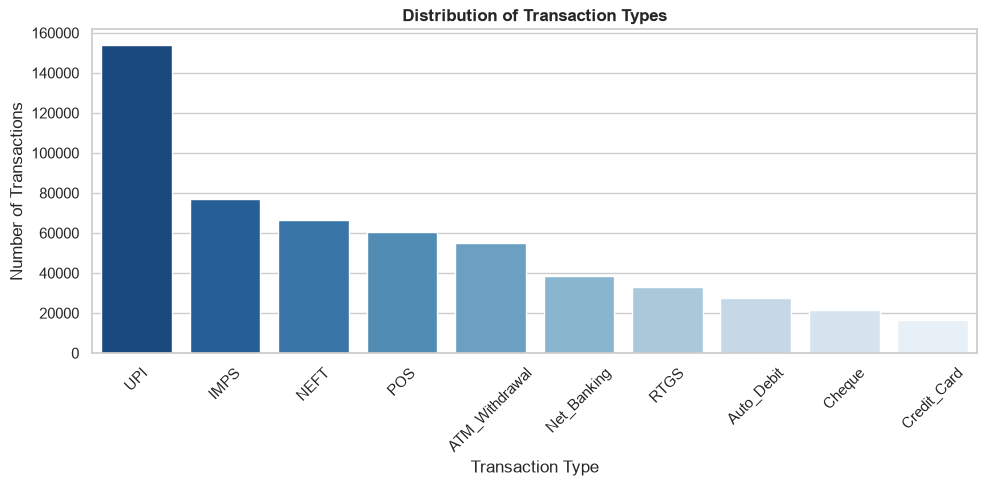

In [14]:
# Transaction Type Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="transaction_type",
              order=df.transaction_type.value_counts().index,
              palette="Blues_r")
plt.title("Distribution of Transaction Types", fontweight="bold")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

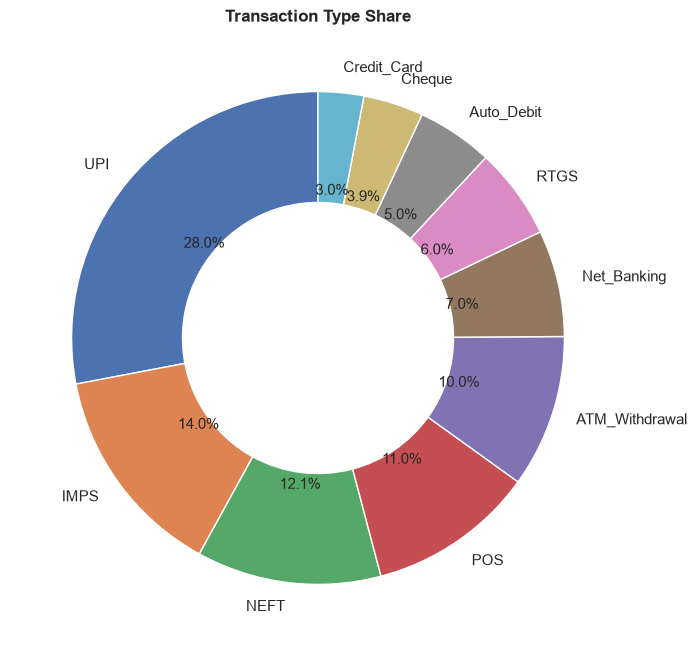

In [15]:
# Transaction Type Share in %
transaction = df.transaction_type.value_counts()
plt.figure(figsize=(8, 8))
plt.pie(transaction.values, labels=transaction.index,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(width=0.45))
plt.title("Transaction Type Share", fontweight="bold")
plt.show()

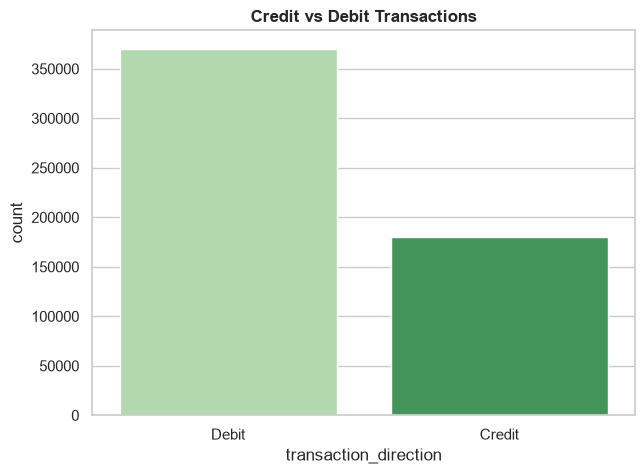

In [16]:
# Credit vs Debit- transaction direction
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='transaction_direction', palette='Greens')
plt.title("Credit vs Debit Transactions", fontweight="bold")
plt.show()

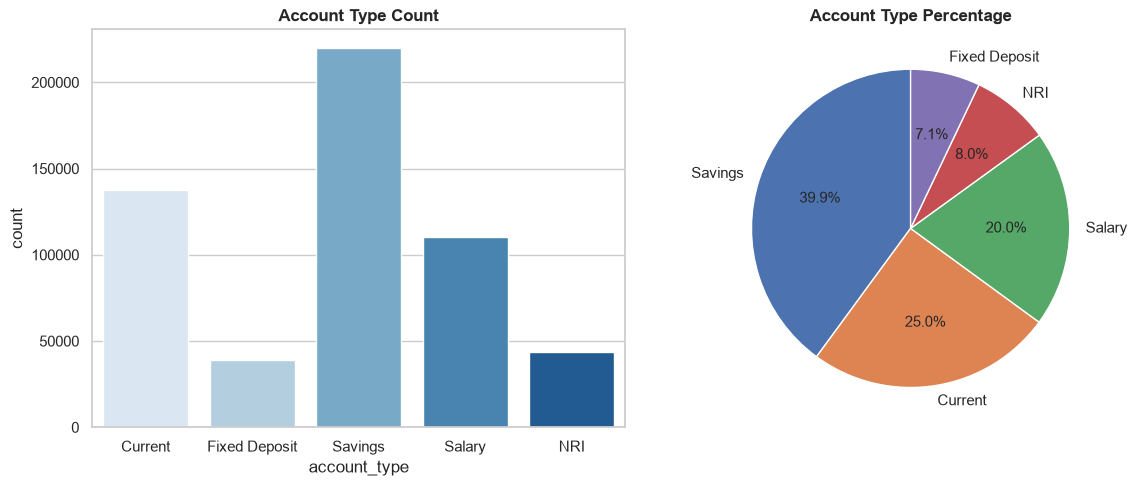

In [17]:
# Account Type and account type share in %
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='account_type', palette='Blues', ax=axes[0])
axes[0].set_title("Account Type Count", fontweight="bold")
account = df.account_type.value_counts()
axes[1].pie(account.values, labels=account.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title("Account Type Percentage", fontweight="bold")
plt.tight_layout()
plt.show()

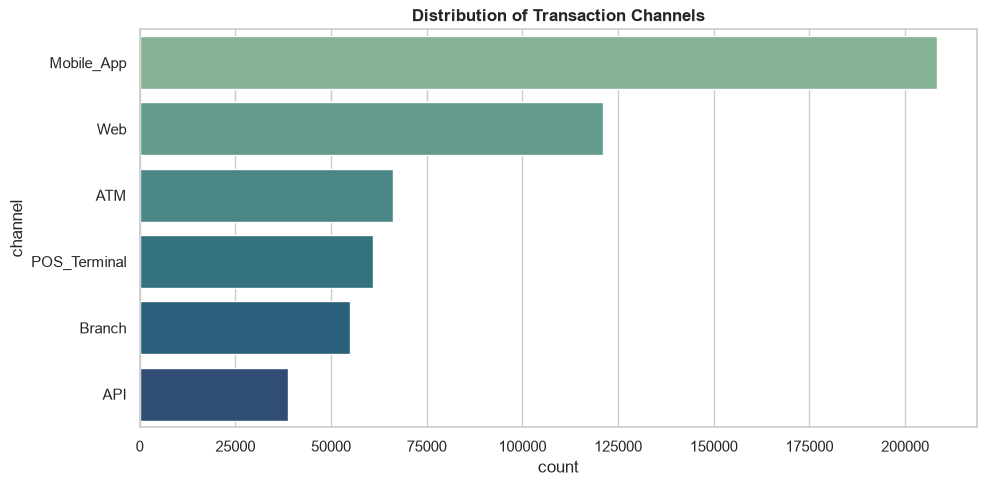

In [18]:
# Channel Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y="channel",
              order=df["channel"].value_counts().index, palette="crest")
plt.title("Distribution of Transaction Channels", fontweight="bold")
plt.tight_layout()
plt.show()

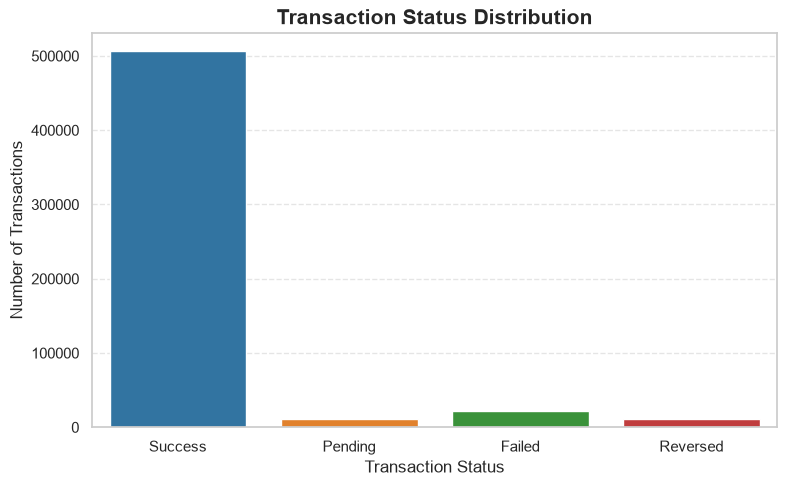

In [19]:
# Transaction Status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='transaction_status', palette='tab10')
plt.title('Transaction Status Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Transaction Status')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

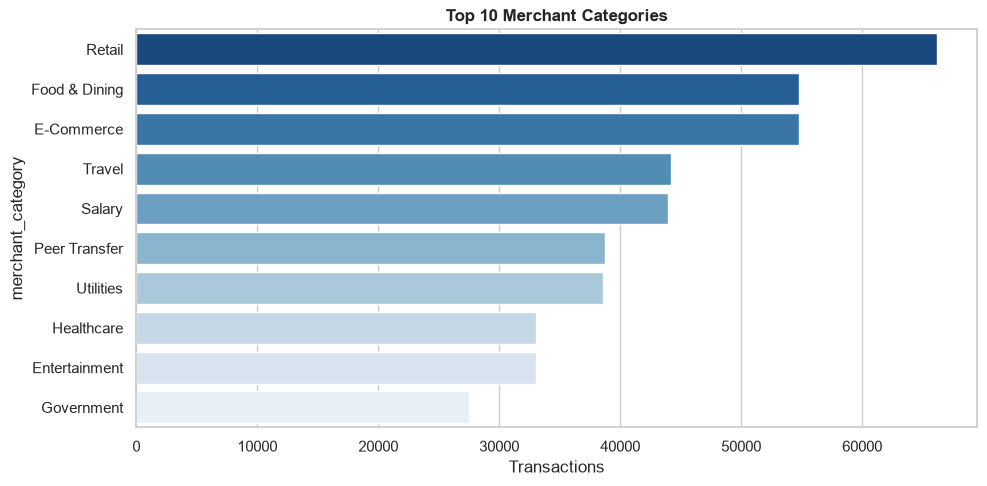

In [20]:
# Top 10 Merchant Categories
merchant = df["merchant_category"].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=merchant.values, y=merchant.index, palette="Blues_r")
plt.title("Top 10 Merchant Categories", fontweight="bold")
plt.xlabel("Transactions")
plt.tight_layout()
plt.show()

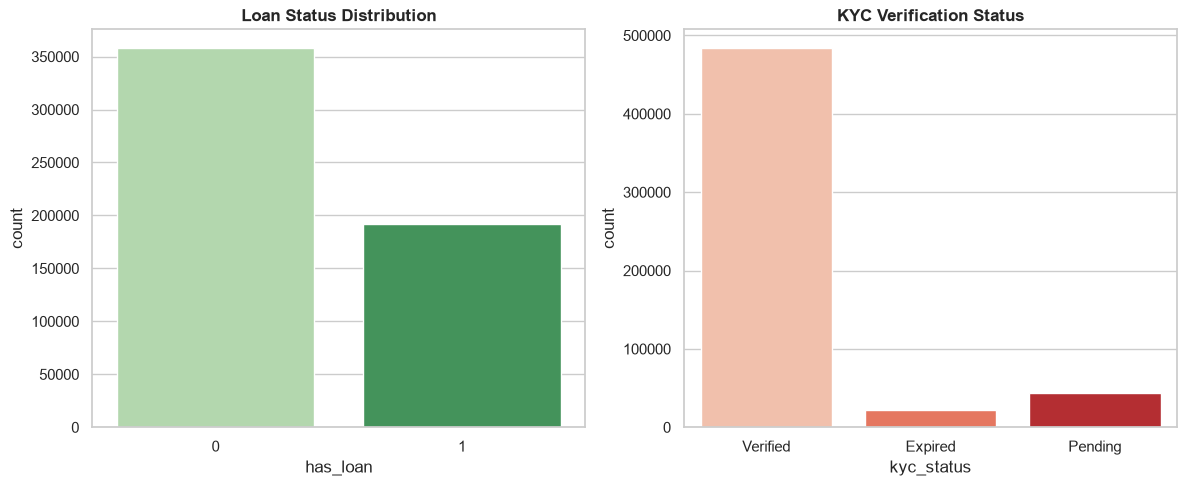

In [21]:
# Loan Status & KYC Status
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='has_loan', palette='Greens', ax=axes[0])
axes[0].set_title("Loan Status Distribution", fontweight="bold")
sns.countplot(data=df, x='kyc_status', palette='Reds', ax=axes[1])
axes[1].set_title("KYC Verification Status", fontweight="bold")
plt.tight_layout()
plt.show()

### Numerical & Comparative Analysis
Examining distributions and outliers for continuous features.

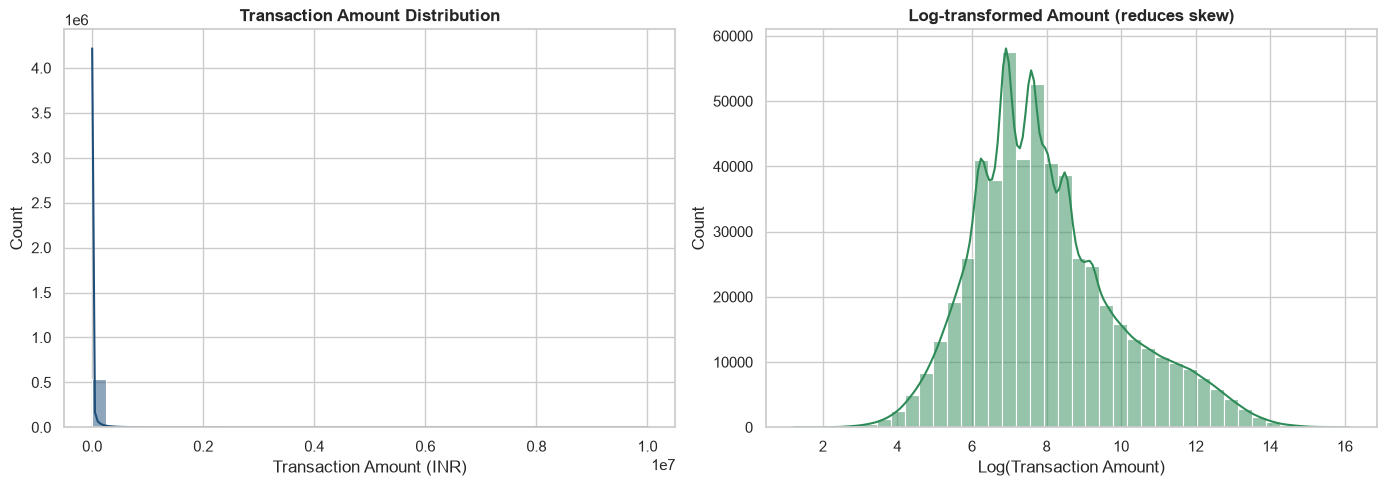

In [22]:
# Transaction Amount Distribution and log distribution of the transaction amount
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='transaction_amount', bins=40, kde=True,
             color='#1F4E79', ax=axes[0])
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Transaction Amount (INR)')
sns.histplot(np.log1p(df["transaction_amount"]), bins=40, kde=True,
             color="#2E8B57", ax=axes[1])
axes[1].set_title("Log-transformed Amount (reduces skew)", fontweight="bold")
axes[1].set_xlabel("Log(Transaction Amount)")
plt.tight_layout()
plt.show()

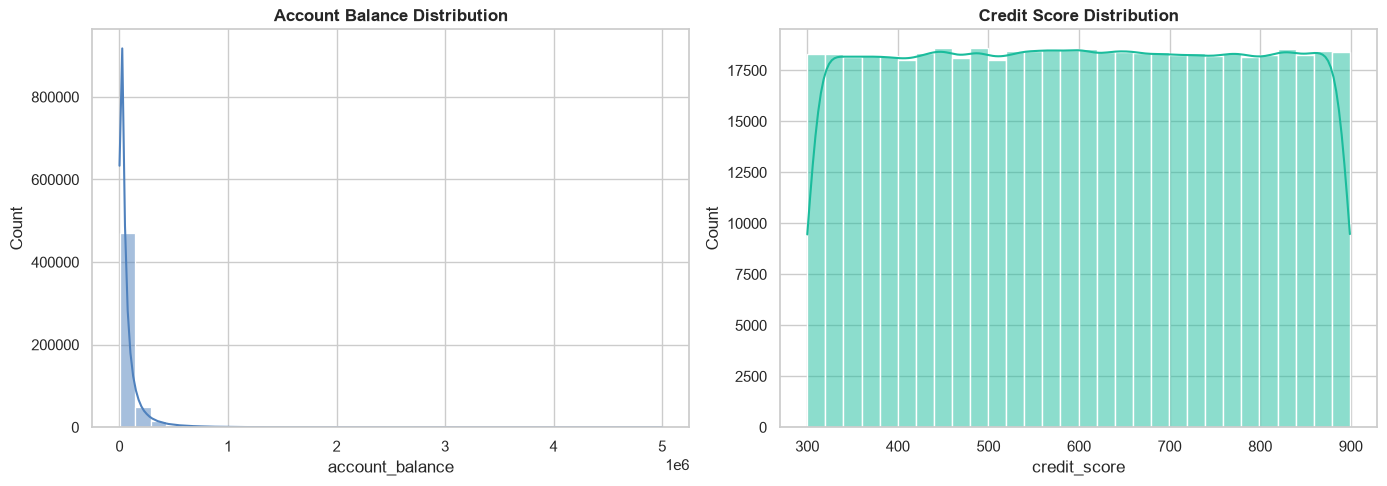

In [23]:
# Distributions: Account Balance & Credit Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x="account_balance", bins=35, kde=True,
             color="#4F81BD", ax=axes[0])
axes[0].set_title("Account Balance Distribution", fontweight="bold")
sns.histplot(data=df, x='credit_score', bins=30, kde=True,
             color='#1ABC9C', ax=axes[1])
axes[1].set_title('Credit Score Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

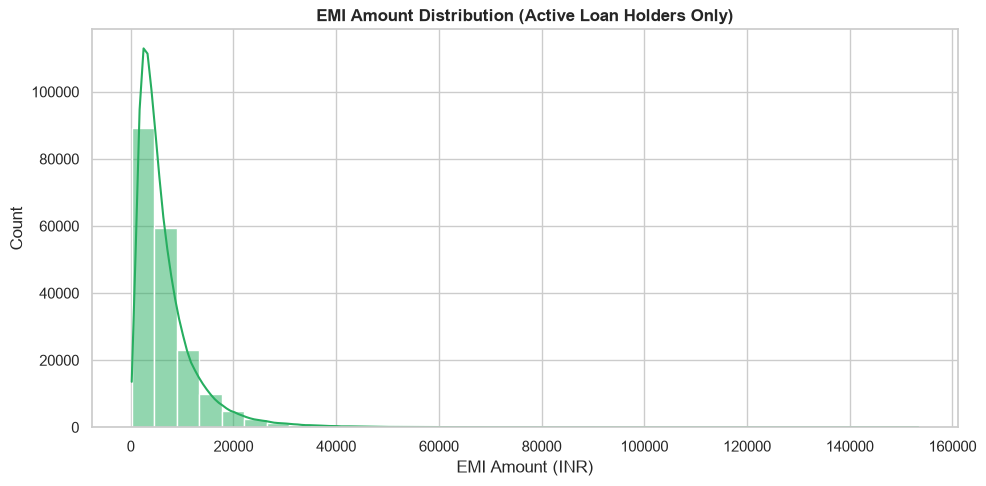

In [24]:
# EMI Amount Distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=df[df['emi_amount'] > 0], x='emi_amount', bins=35,
             kde=True, color='#27AE60')
plt.title('EMI Amount Distribution (Active Loan Holders Only)', fontweight='bold')
plt.xlabel('EMI Amount (INR)')
plt.tight_layout()
plt.show()

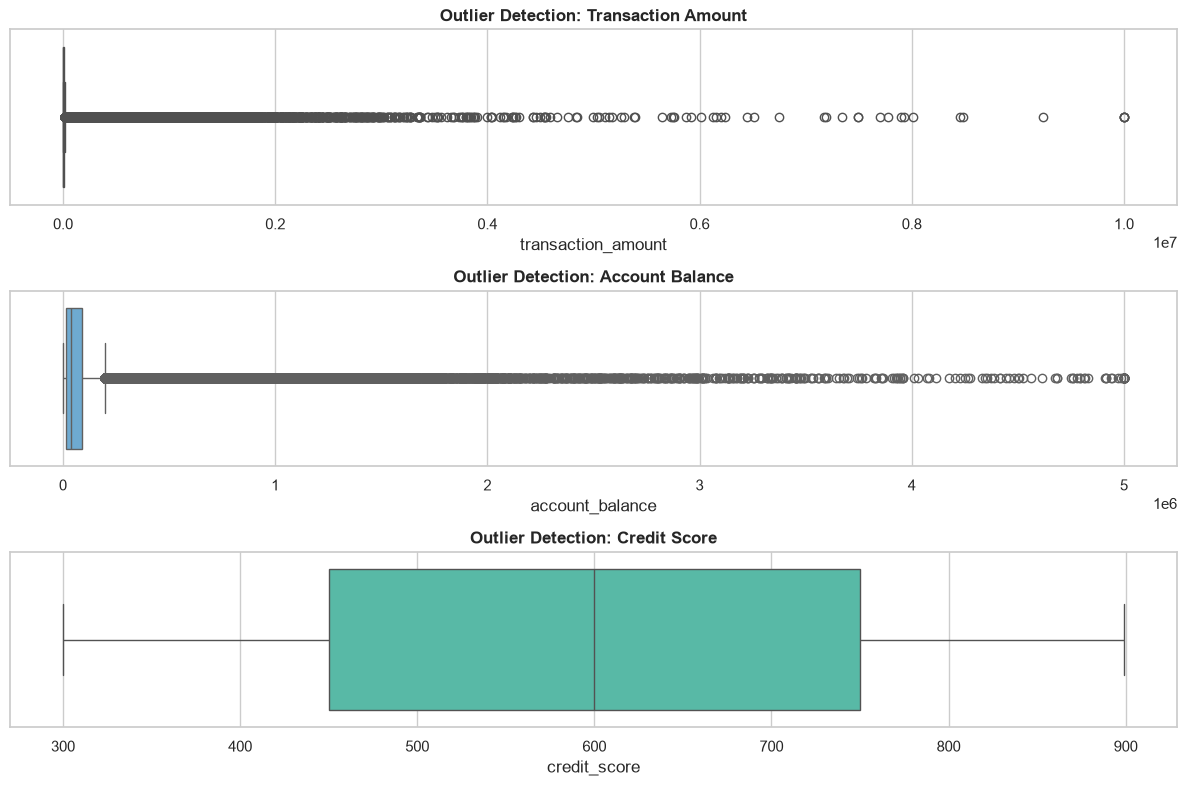

transaction_amount: 88976 outliers (16.18%)
account_balance: 53567 outliers (9.74%)
credit_score: 0 outliers (0.00%)


In [25]:
# Outlier Detection — Boxplots(transaction amount and credit score)
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for ax, col, color in zip(axes,
                           ['transaction_amount', 'account_balance', 'credit_score'],
                           ['#4F81BD', '#5DADE2', '#48C9B0']):
    sns.boxplot(data=df, x=col, color=color, ax=ax)
    ax.set_title(f'Outlier Detection: {col.replace("_"," ").title()}', fontweight='bold')
plt.tight_layout()
plt.show()

# IQR-based outlier counts
for col in ['transaction_amount', 'account_balance', 'credit_score']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {n_outliers} outliers ({n_outliers/len(df)*100:.2f}%)")

**Observation:**
- `transaction_amount` shows a strong right skew; log-transformation confirms most transactions are low-value with a tail of high-value outliers. These high-value outliers are candidates for elevated fraud scrutiny.
- `account_balance` exhibits similar right-skew which is a segment of high-balance accounts behaves very differently from the median customer.
- `credit_score` distribution indicates the customer base is spread across creditworthiness bands; no extreme concentration at either end.
- IQR outlier counts above confirm whether outlier treatment is necessary before any downstream modelling.

### Time-Series Analysis

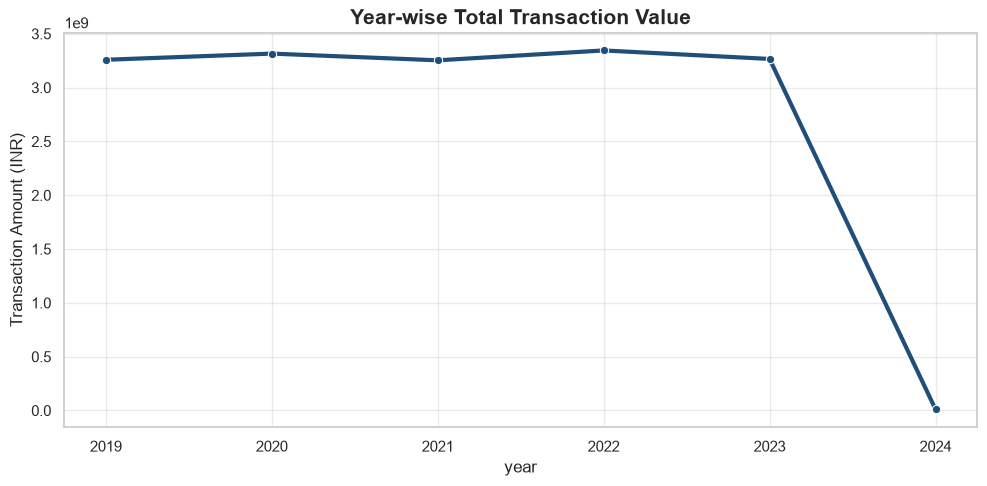

In [26]:
# Year-wise Total Transaction Value
yearly = df.groupby("year")["transaction_amount"].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly, x="year", y="transaction_amount",
             marker="o", linewidth=3, color="#1F4E79")
plt.title("Year-wise Total Transaction Value", fontsize=15, fontweight="bold")
plt.ylabel("Transaction Amount (INR)")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

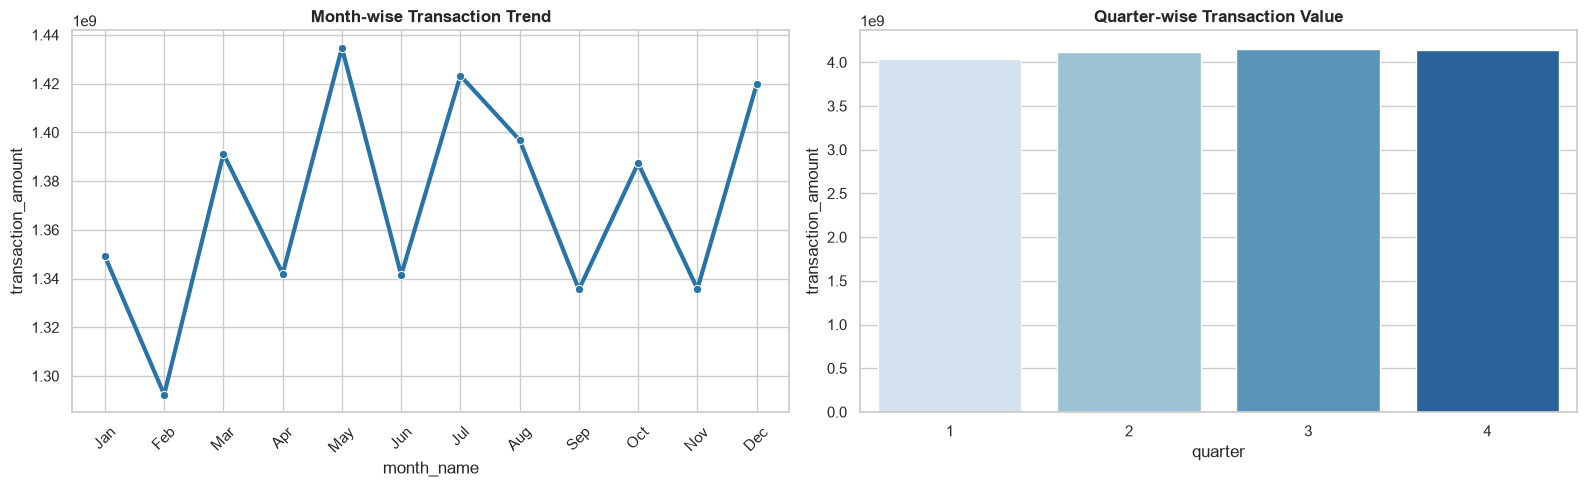

In [27]:
# Month-wise & Quarter-wise Trends
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = df.groupby("month_name")["transaction_amount"].sum().reset_index()
monthly["month_name"] = pd.Categorical(monthly["month_name"],
                                        categories=month_order, ordered=True)
monthly = monthly.sort_values("month_name")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=monthly, x="month_name", y="transaction_amount",
             marker="o", linewidth=3, color="#2874A6", ax=axes[0])
axes[0].set_title("Month-wise Transaction Trend", fontweight="bold")
axes[0].tick_params(axis='x', rotation=45)

quarter = df.groupby("quarter")["transaction_amount"].sum().reset_index()
sns.barplot(data=quarter, x="quarter", y="transaction_amount",
            palette="Blues", ax=axes[1])
axes[1].set_title("Quarter-wise Transaction Value", fontweight="bold")
plt.tight_layout()
plt.show()

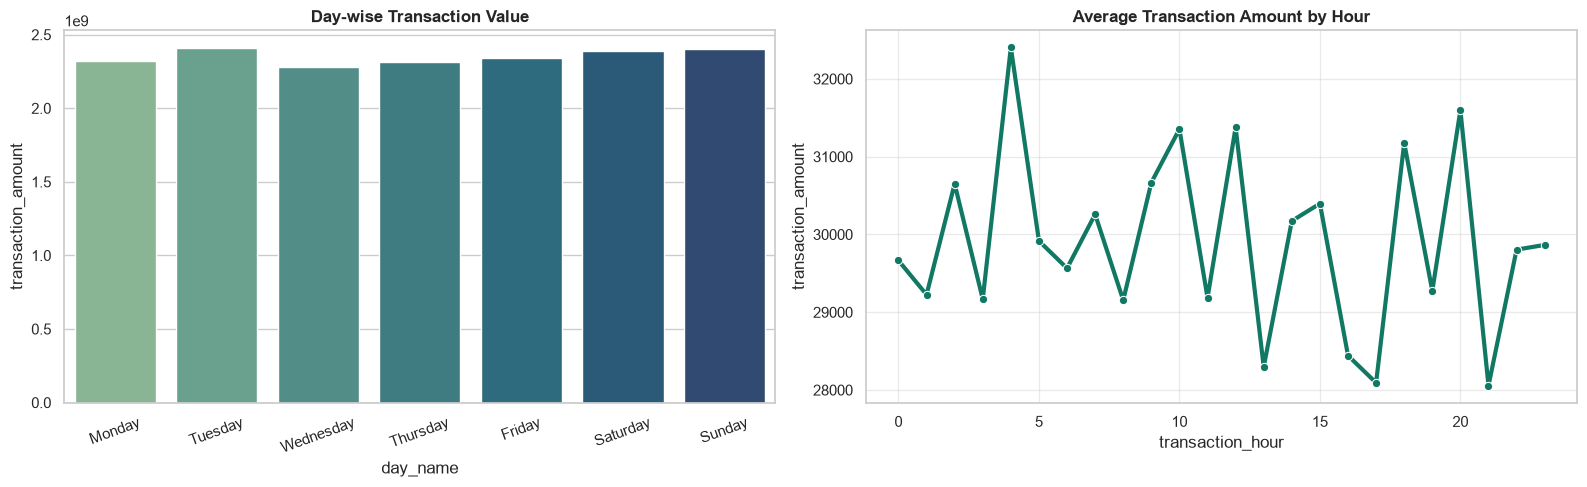

In [28]:
# Day-wise and Hour-wise Trends
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day = df.groupby("day_name")["transaction_amount"].sum().reset_index()
day["day_name"] = pd.Categorical(day["day_name"], categories=day_order, ordered=True)
day = day.sort_values("day_name")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=day, x="day_name", y="transaction_amount",
            palette="crest", ax=axes[0])
axes[0].set_title("Day-wise Transaction Value", fontweight="bold")
axes[0].tick_params(axis='x', rotation=20)

hour_avg = df.groupby("transaction_hour")["transaction_amount"].mean().reset_index()
sns.lineplot(data=hour_avg, x="transaction_hour", y="transaction_amount",
             marker="o", linewidth=3, color="#117864", ax=axes[1])
axes[1].set_title("Average Transaction Amount by Hour", fontweight="bold")
axes[1].grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Bivariate Analysis

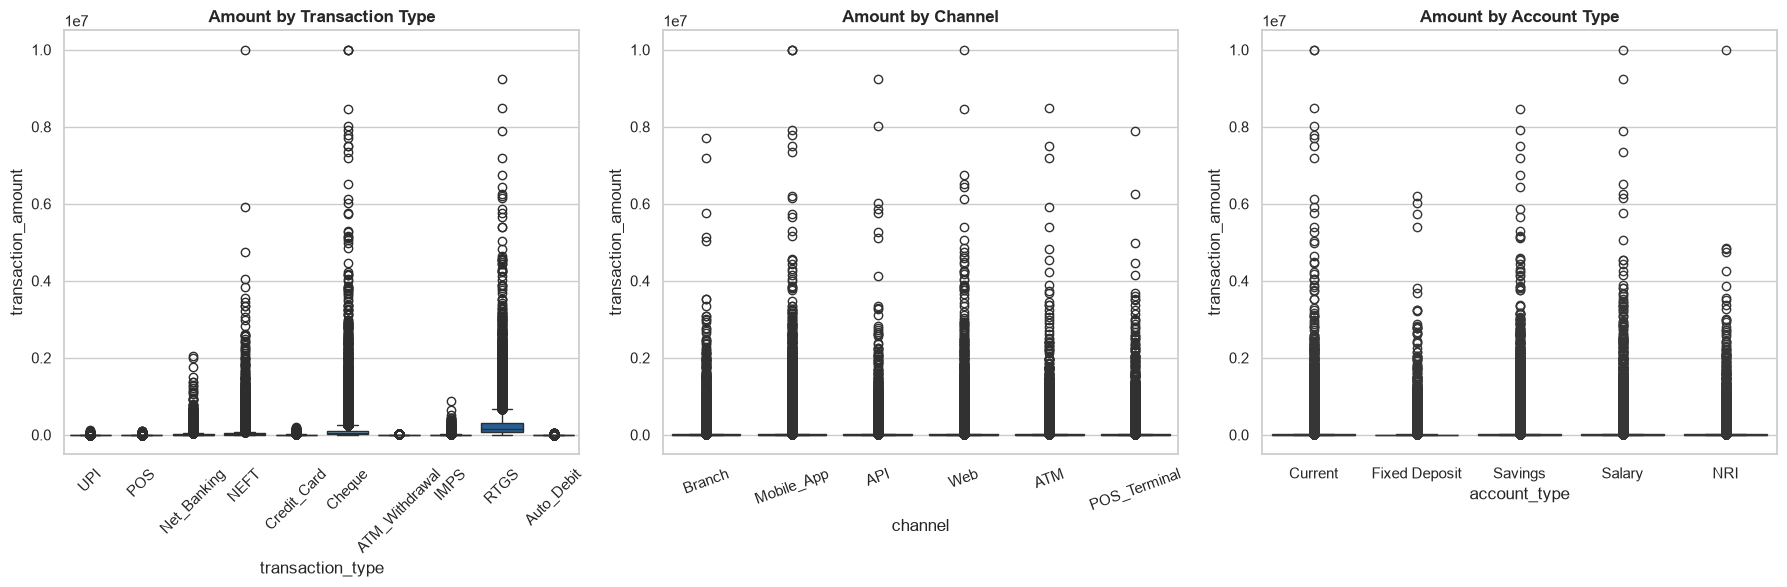

In [29]:
# Transaction Amount by Type, Channel, Account Type
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(data=df, x='transaction_type', y='transaction_amount',
            palette='Blues', ax=axes[0])
axes[0].set_title('Amount by Transaction Type', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='channel', y='transaction_amount',
            palette='crest', ax=axes[1])
axes[1].set_title('Amount by Channel', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='account_type', y='transaction_amount',
            palette='Blues', ax=axes[2])
axes[2].set_title('Amount by Account Type', fontweight='bold')
plt.tight_layout()
plt.show()

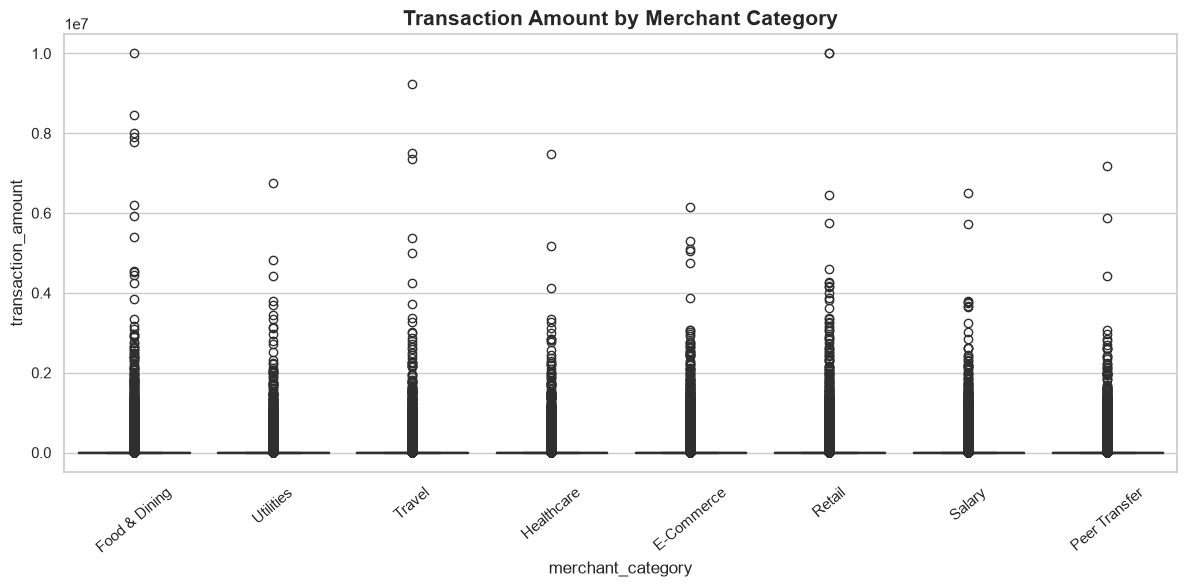

In [30]:
# Amount by Top Merchant Categories
top_merchants = df['merchant_category'].value_counts().head(8).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['merchant_category'].isin(top_merchants)],
            x='merchant_category', y='transaction_amount', palette='Blues')
plt.title('Transaction Amount by Merchant Category', fontsize=15, fontweight='bold')
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

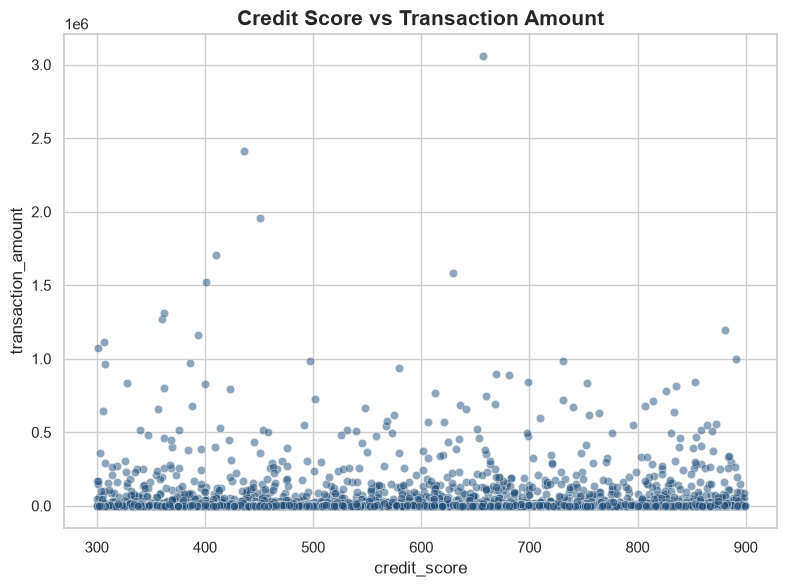

In [31]:
# Credit Score vs Transaction Amount
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(5000, random_state=42),
                x='credit_score', y='transaction_amount',
                alpha=0.5, color='#1F4E79')
plt.title('Credit Score vs Transaction Amount', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

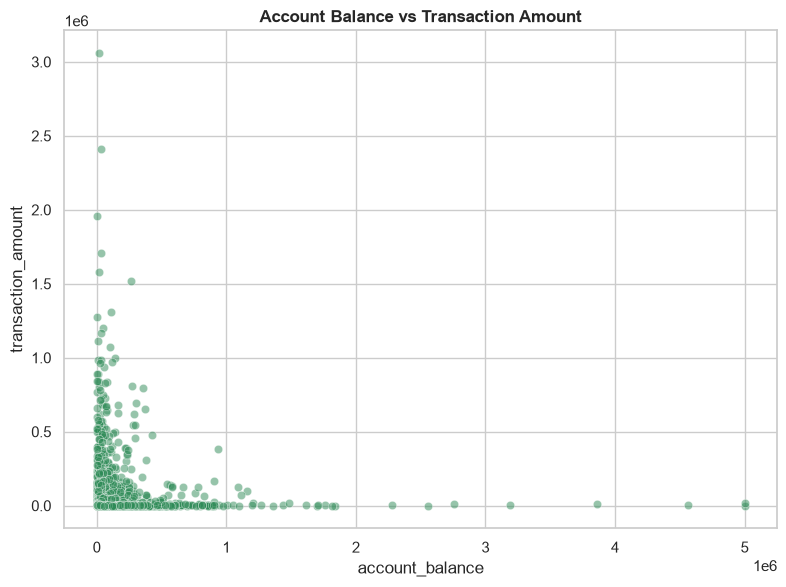

In [32]:
# Account Balance vs Transaction Amount
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(5000, random_state=42),
                x='account_balance', y='transaction_amount',
                alpha=0.5, color='#2E8B57')
plt.title("Account Balance vs Transaction Amount", fontweight="bold")
plt.tight_layout()
plt.show()

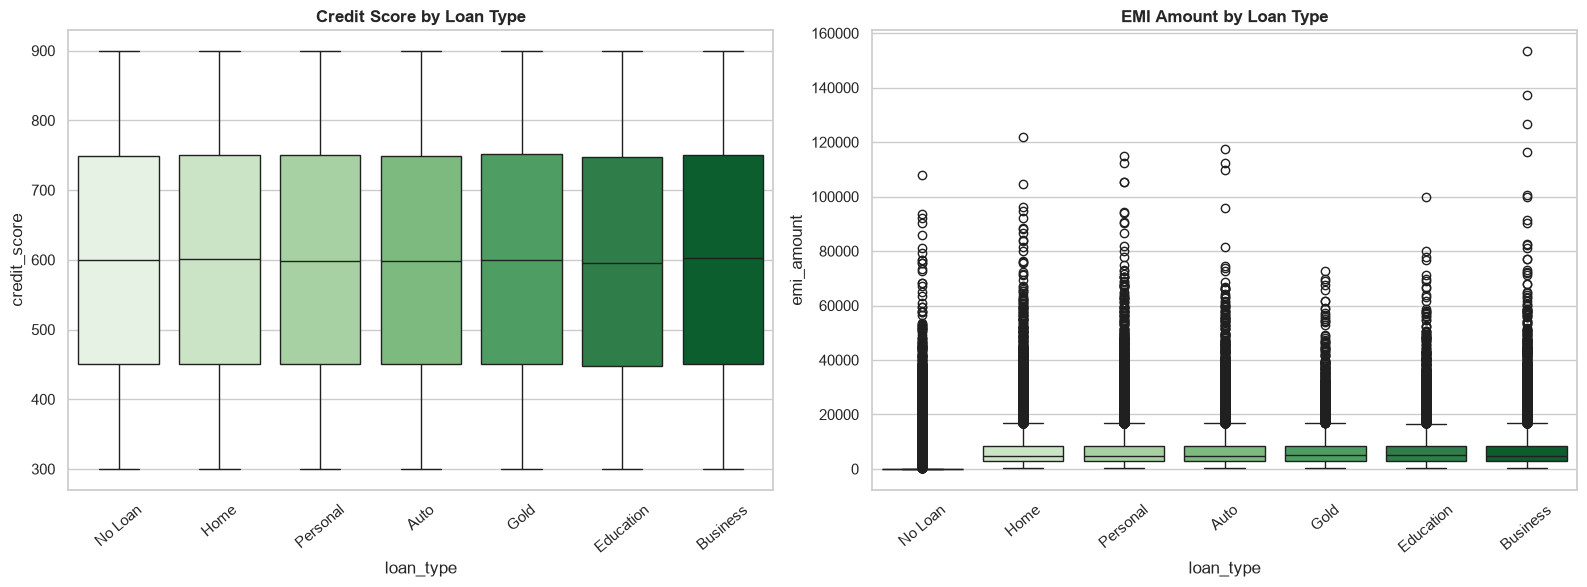

In [33]:
# Credit Score and EMI by Loan Type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x='loan_type', y='credit_score',
            palette='Greens', ax=axes[0])
axes[0].set_title('Credit Score by Loan Type', fontweight='bold')
axes[0].tick_params(axis='x', rotation=40)

sns.boxplot(data=df, x='loan_type', y='emi_amount',
            palette='Greens', ax=axes[1])
axes[1].set_title('EMI Amount by Loan Type', fontweight='bold')
axes[1].tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()

**Observation:**
- RTGS and NEFT tend to carry higher median transaction values, consistent with their use for large-value transfers.
- Branch and POS channels show a wider spread of transaction amounts compared to mobile banking.
- The scatterplot of credit score vs. transaction amount shows no strong linear relationship, indicating credit score alone does not predict transaction size.
- Home Loan holders expectedly carry the highest EMI amounts; Personal Loan customers show the widest variability.

## Fraud Analysis

**Hypotheses being tested in this section:**
1. Fraud rate varies significantly across transaction types and channels.
2. Night-time hours (10 PM– 4 AM) will show elevated fraud rates.
3. Certain merchant categories carry disproportionate fraud risk.
4. Fraudulent transactions will tend to cluster in specific states.
5. Fraudulent transactions and genuine transactions show distinct distributions in amount and credit score.

---

Total Transactions : 550,000
Genuine (0)        : 545,127  (99.11%)
Fraudulent (1)     : 4,873  (0.89%)
Imbalance Ratio    : 111.9:1 (genuine:fraud)


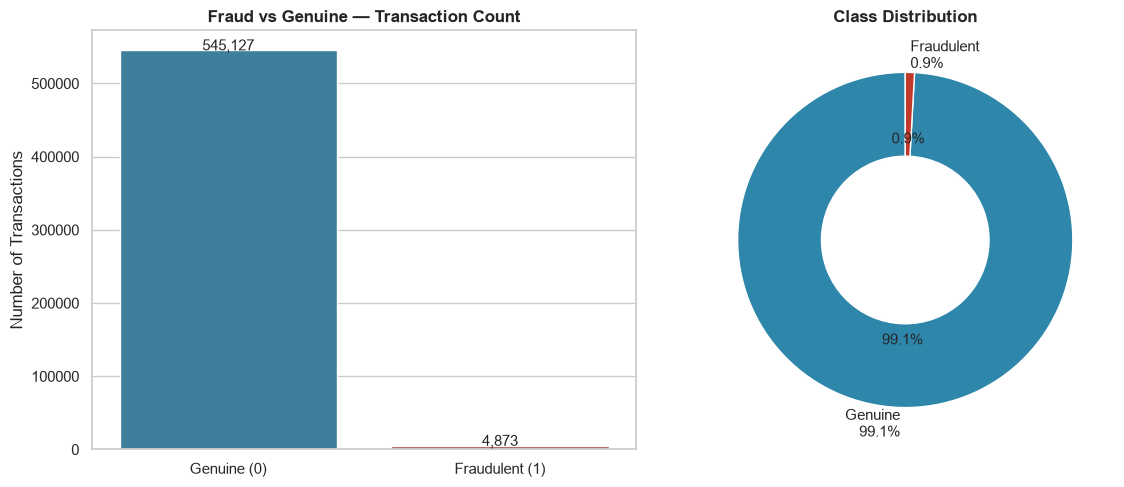

In [34]:
#Class Imbalance Analysis
fraud_counts = df['is_fraud'].value_counts()
fraud_rate   = df['is_fraud'].mean() * 100
genuine_rate = 100 - fraud_rate

print(f"Total Transactions : {len(df):,}")
print(f"Genuine (0)        : {fraud_counts[0]:,}  ({genuine_rate:.2f}%)")
print(f"Fraudulent (1)     : {fraud_counts[1]:,}  ({fraud_rate:.2f}%)")
print(f"Imbalance Ratio    : {fraud_counts[0]/fraud_counts[1]:.1f}:1 (genuine:fraud)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count bar
sns.barplot(x=['Genuine (0)', 'Fraudulent (1)'],
            y=fraud_counts.values, palette=['#2E86AB','#C0392B'], ax=axes[0])
axes[0].set_title('Fraud vs Genuine — Transaction Count', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for bar, val in zip(axes[0].patches, fraud_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=11)

# Percentage pie
axes[1].pie([genuine_rate, fraud_rate],
            labels=[f'Genuine\n{genuine_rate:.1f}%', f'Fraudulent\n{fraud_rate:.1f}%'],
            colors=['#2E86AB','#C0392B'], startangle=90,
            wedgeprops=dict(width=0.5), autopct='%1.1f%%')
axes[1].set_title('Class Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

**Finding- Class Imbalance:**

The dataset contains substantially more genuine transactions than fraudulent ones, indicating a class imbalance. This should be considered in any future fraud detection model, as relying solely on accuracy may produce misleading results.

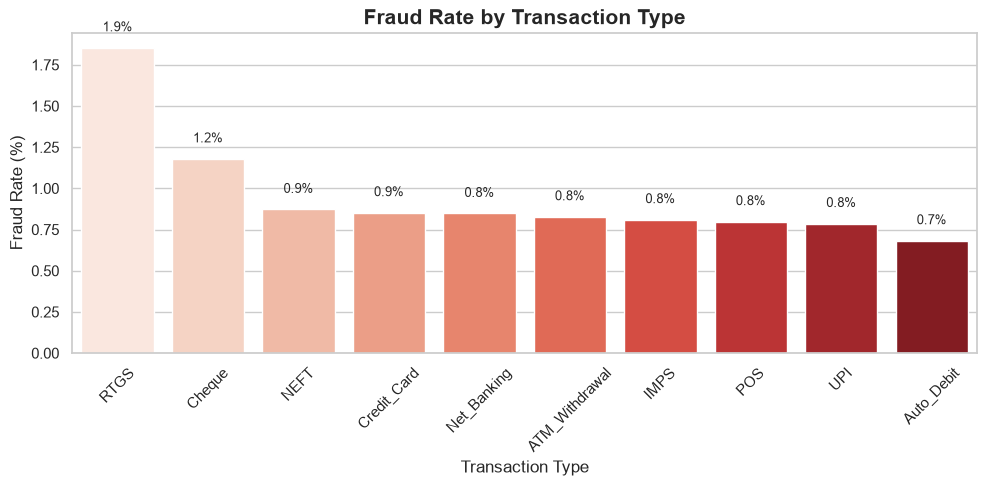

Highest fraud rate — Transaction Type: RTGS (1.85%)


In [35]:
# Fraud Rate by Transaction Type
fraud_type = (df.groupby('transaction_type')['is_fraud']
                .mean().mul(100)
                .sort_values(ascending=False)
                .reset_index())

plt.figure(figsize=(10, 5))
bars = sns.barplot(data=fraud_type, x='transaction_type', y='is_fraud', palette='Reds')
plt.title('Fraud Rate by Transaction Type', fontsize=15, fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
for bar, val in zip(bars.patches, fraud_type['is_fraud']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
              f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Highest fraud rate — Transaction Type:", fraud_type.iloc[0]['transaction_type'],
      f"({fraud_type.iloc[0]['is_fraud']:.2f}%)")

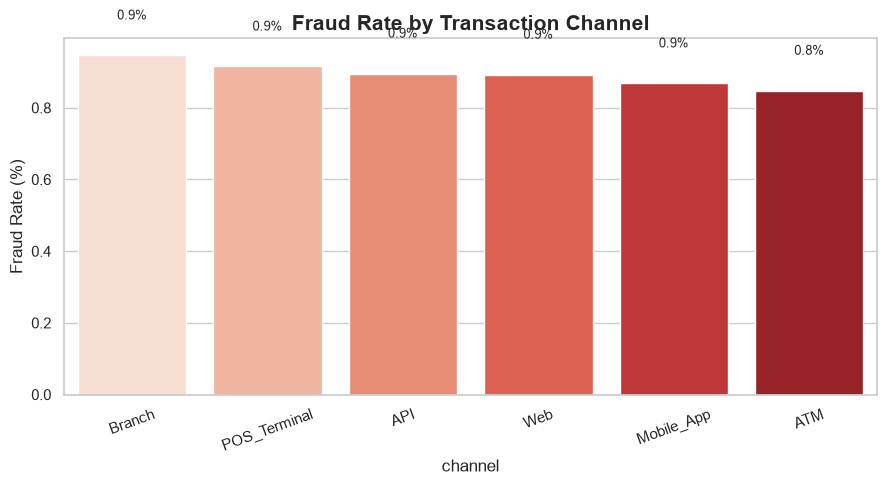

Highest fraud rate — Channel: Branch (0.95%)


In [36]:
# Fraud Rate by Channel
fraud_channel = (df.groupby('channel')['is_fraud']
                   .mean().mul(100)
                   .sort_values(ascending=False)
                   .reset_index())

plt.figure(figsize=(9, 5))
bars = sns.barplot(data=fraud_channel, x='channel', y='is_fraud', palette='Reds')
plt.title('Fraud Rate by Transaction Channel', fontsize=15, fontweight='bold')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=20)
for bar, val in zip(bars.patches, fraud_channel['is_fraud']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
              f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Highest fraud rate — Channel:", fraud_channel.iloc[0]['channel'],
      f"({fraud_channel.iloc[0]['is_fraud']:.2f}%)")

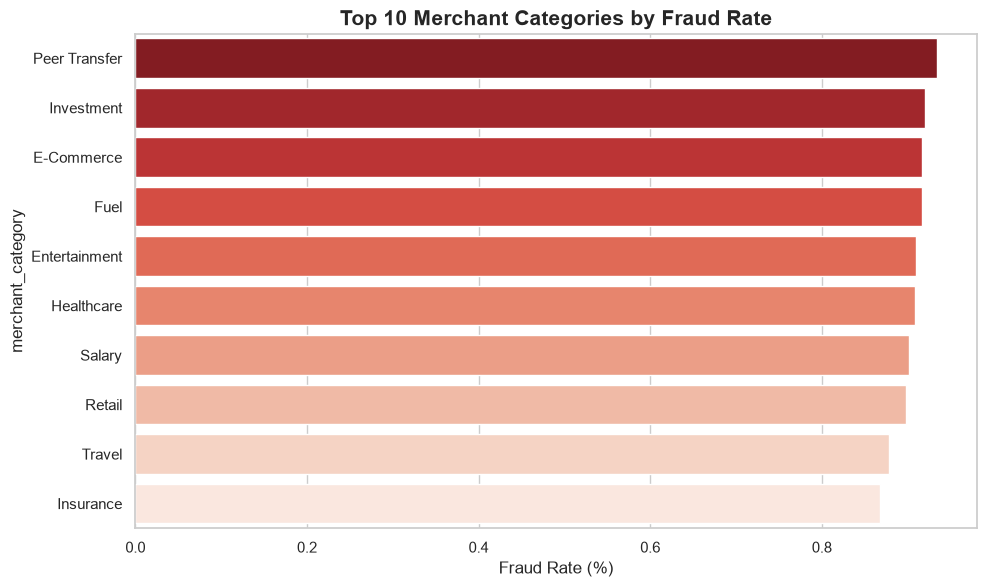

In [37]:
# Top Merchant Categories by Fraud Rate
merchant_fraud = (df.groupby('merchant_category')['is_fraud']
                    .mean().mul(100)
                    .sort_values(ascending=False)
                    .head(10).reset_index())

plt.figure(figsize=(10, 6))
sns.barplot(data=merchant_fraud, x='is_fraud', y='merchant_category', palette='Reds_r')
plt.title('Top 10 Merchant Categories by Fraud Rate', fontsize=15, fontweight='bold')
plt.xlabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

In [38]:
merchant_fraud.head(1)

,merchant_category,is_fraud
0,Peer Transfer,0.934121


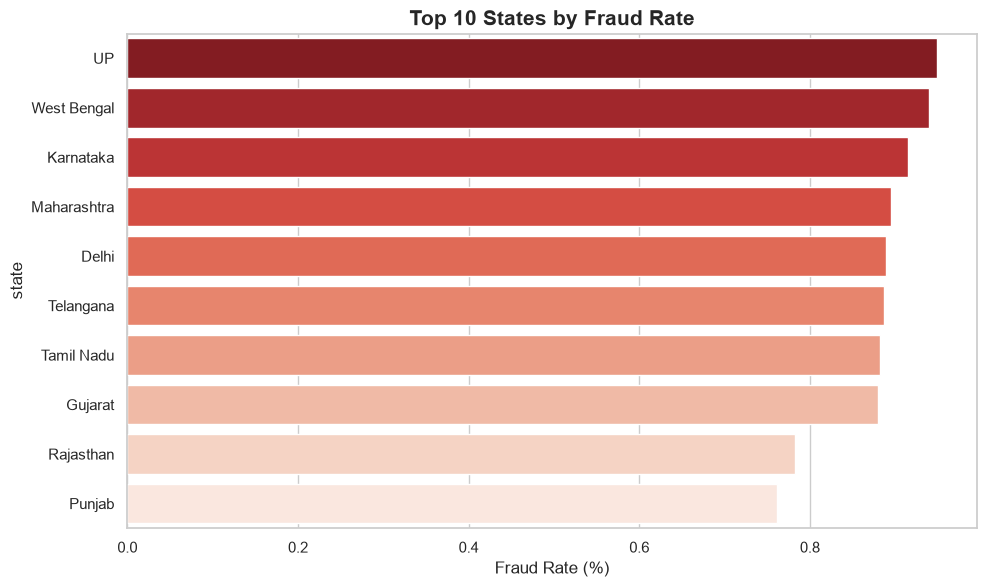

Top 3 high-risk states:
      state  is_fraud
         UP  0.948421
West Bengal  0.939704
  Karnataka  0.914439


In [39]:
# Top States by Fraud Rate
state_fraud = (df.groupby('state')['is_fraud']
                 .mean().mul(100)
                 .sort_values(ascending=False)
                 .head(10).reset_index())

plt.figure(figsize=(10, 6))
sns.barplot(data=state_fraud, x='is_fraud', y='state', palette='Reds_r')
plt.title('Top 10 States by Fraud Rate', fontsize=15, fontweight='bold')
plt.xlabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

print("Top 3 high-risk states:")
print(state_fraud.head(3).to_string(index=False))

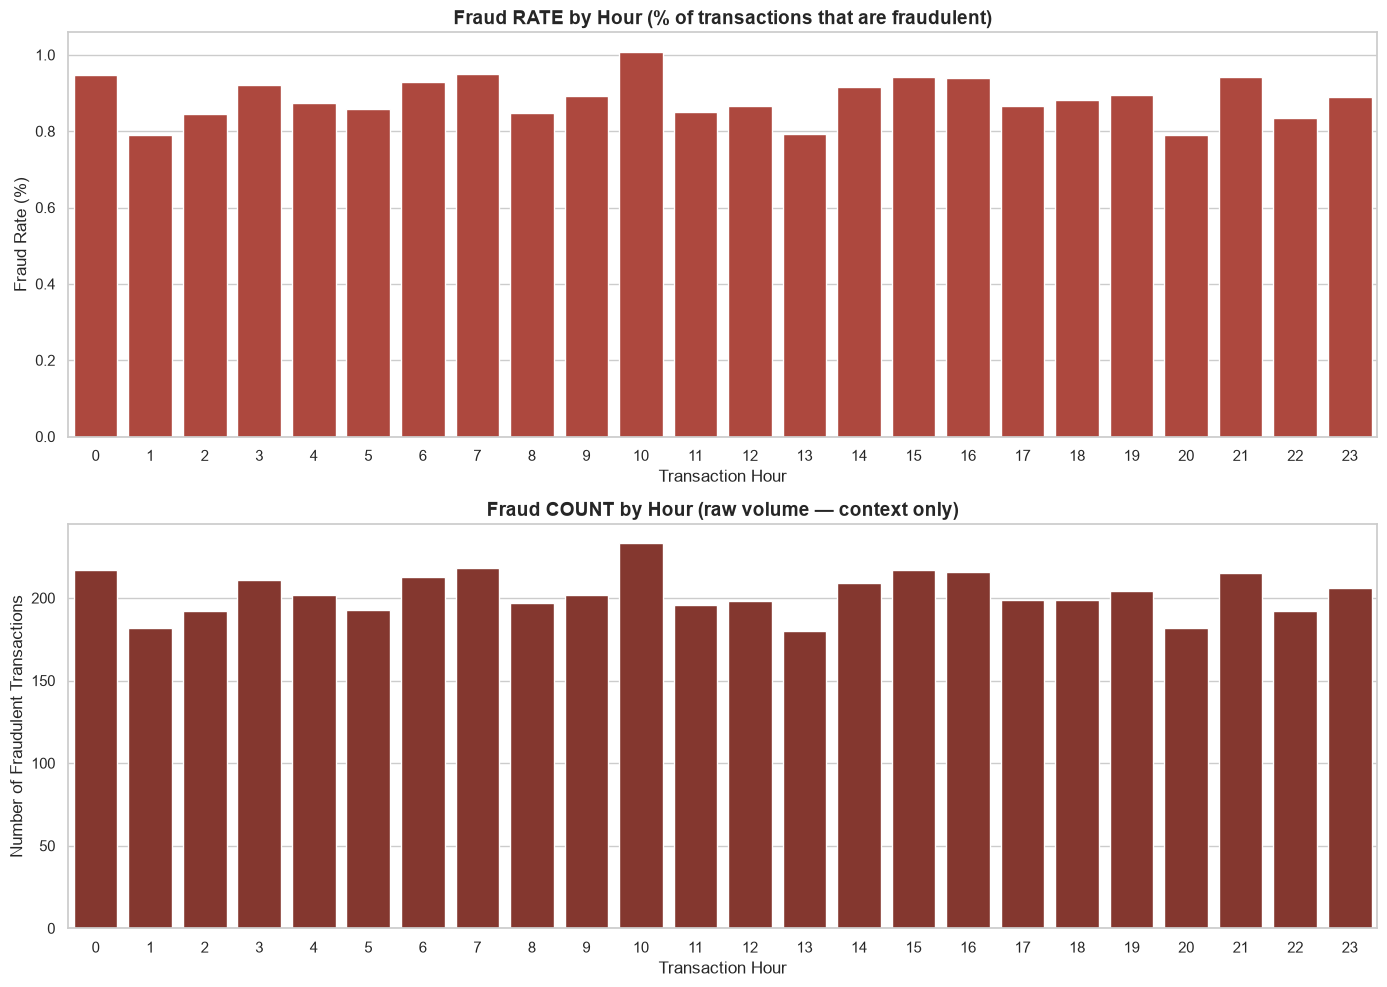

Peak fraud rate: Hour 10 at 1.01%


In [40]:
# Fraud Rate by Hour (rate, not raw count)
# Using RATE avoids the trap of mistaking high-volume hours for high-risk hours.
hour_fraud_rate = (df.groupby('transaction_hour')['is_fraud']
                     .mean().mul(100).reset_index(name='fraud_rate'))
hour_fraud_count = (df[df['is_fraud']==1]
                      .groupby('transaction_hour').size()
                      .reset_index(name='fraud_count'))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Fraud RATE by hour
sns.barplot(data=hour_fraud_rate, x='transaction_hour', y='fraud_rate',
            color='#C0392B', ax=axes[0])
axes[0].set_title('Fraud RATE by Hour (% of transactions that are fraudulent)',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xlabel('Transaction Hour')

# Fraud COUNT by hour (for reference)
sns.barplot(data=hour_fraud_count, x='transaction_hour', y='fraud_count',
            color='#922B21', ax=axes[1])
axes[1].set_title('Fraud COUNT by Hour (raw volume — context only)',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Fraudulent Transactions')
axes[1].set_xlabel('Transaction Hour')

plt.tight_layout()
plt.show()

# Peak fraud rate hour
peak_hour = hour_fraud_rate.loc[hour_fraud_rate['fraud_rate'].idxmax()]
print(f"Peak fraud rate: Hour {int(peak_hour['transaction_hour'])} at {peak_hour['fraud_rate']:.2f}%")

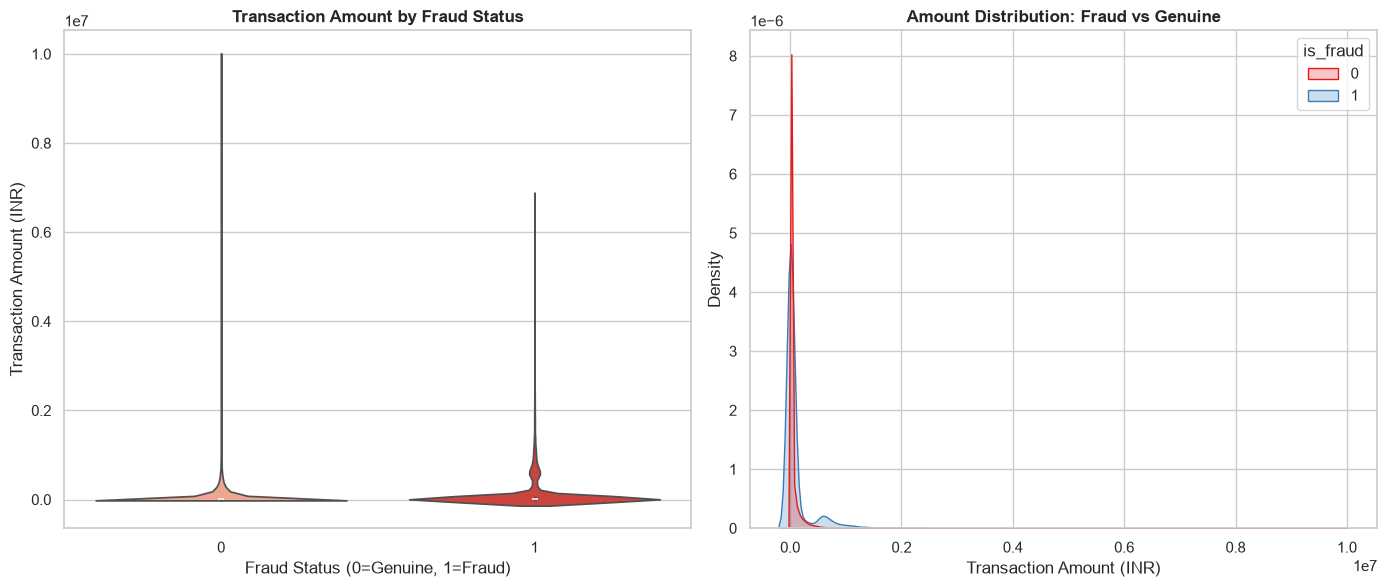

Median Transaction Amount — Genuine: ₹2,031
Median Transaction Amount — Fraudulent: ₹2,692


In [41]:
# Fraud vs Transaction Amount — Violin + KDE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=df, x='is_fraud', y='transaction_amount',
               palette='Reds', ax=axes[0])
axes[0].set_title('Transaction Amount by Fraud Status', fontweight='bold')
axes[0].set_xlabel('Fraud Status (0=Genuine, 1=Fraud)')
axes[0].set_ylabel('Transaction Amount (INR)')

sns.kdeplot(data=df, x="transaction_amount", hue="is_fraud",
            fill=True, common_norm=False, palette="Set1", ax=axes[1])
axes[1].set_title("Amount Distribution: Fraud vs Genuine", fontweight="bold")
axes[1].set_xlabel("Transaction Amount (INR)")

plt.tight_layout()
plt.show()

# Quantitative comparison
for label, name in [(0,'Genuine'), (1,'Fraudulent')]:
    med = df[df['is_fraud']==label]['transaction_amount'].median()
    print(f"Median Transaction Amount — {name}: ₹{med:,.0f}")

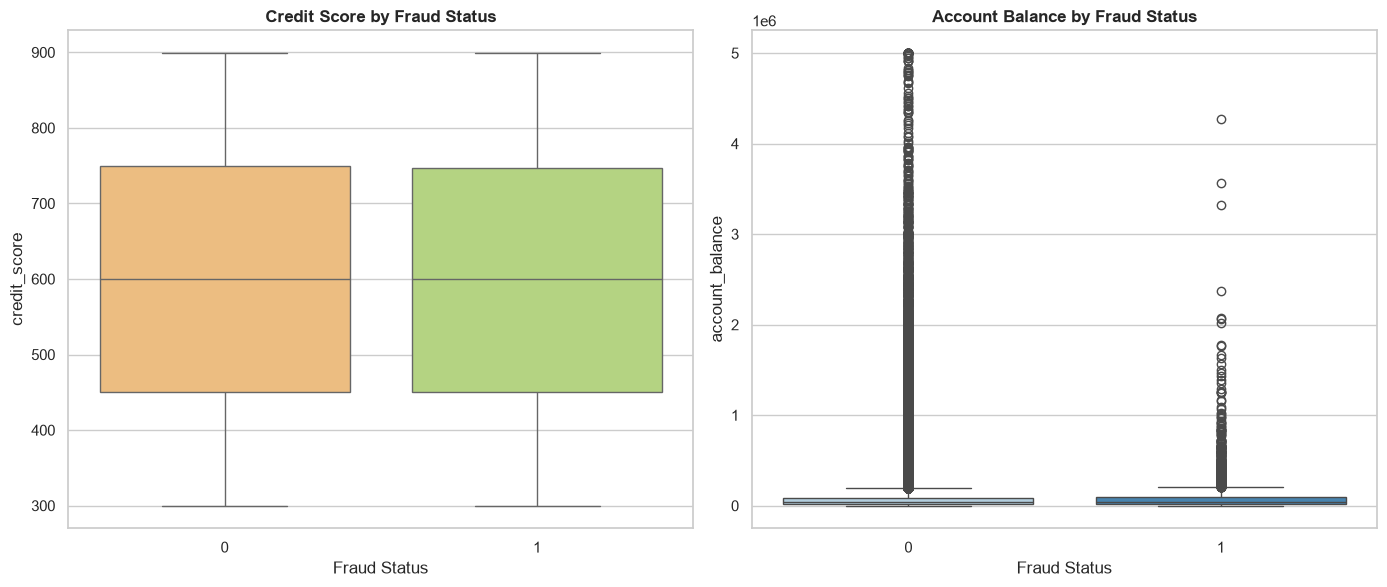

Genuine — Median Credit Score: 600 | Median Account Balance: ₹36,424
Fraudulent — Median Credit Score: 600 | Median Account Balance: ₹36,238


In [42]:
# Fraud vs Credit Score & Account Balance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='is_fraud', y='credit_score',
            palette='RdYlGn', ax=axes[0])
axes[0].set_title('Credit Score by Fraud Status', fontweight='bold')
axes[0].set_xlabel('Fraud Status')

sns.boxplot(data=df, x='is_fraud', y='account_balance',
            palette='Blues', ax=axes[1])
axes[1].set_title('Account Balance by Fraud Status', fontweight='bold')
axes[1].set_xlabel('Fraud Status')

plt.tight_layout()
plt.show()

for label, name in [(0,'Genuine'), (1,'Fraudulent')]:
    cs = df[df['is_fraud']==label]['credit_score'].median()
    ab = df[df['is_fraud']==label]['account_balance'].median()
    print(f"{name} — Median Credit Score: {cs:.0f} | Median Account Balance: ₹{ab:,.0f}")

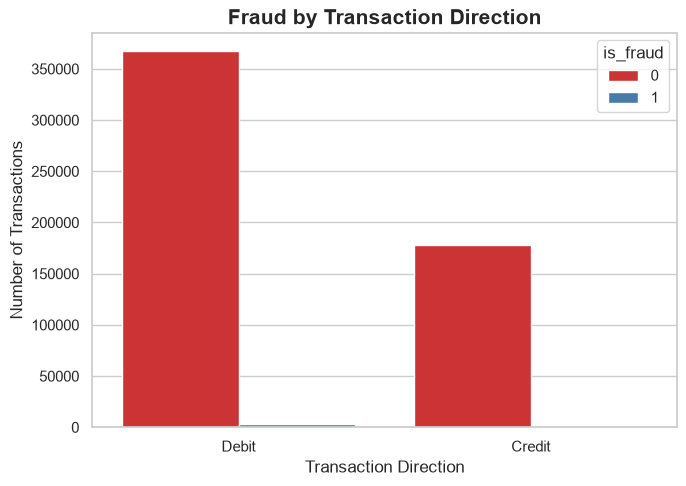

transaction_direction
Credit    0.92
Debit     0.87
Name: is_fraud, dtype: float64


In [43]:
# Fraud by Transaction Direction
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='transaction_direction', hue='is_fraud', palette='Set1')
plt.title('Fraud by Transaction Direction', fontsize=15, fontweight='bold')
plt.xlabel('Transaction Direction')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

# Fraud rate by direction
print(df.groupby('transaction_direction')['is_fraud'].mean().mul(100).round(2))

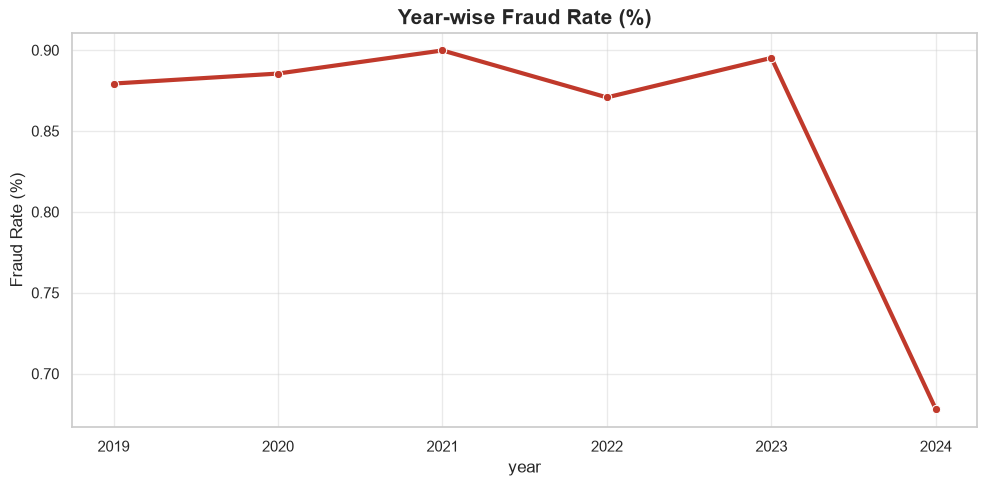

In [44]:
# Year-wise Fraud Rate Trend
fraud_year = (df.groupby('year')['is_fraud']
                .mean().mul(100).reset_index())
plt.figure(figsize=(10, 5))
sns.lineplot(data=fraud_year, x='year', y='is_fraud',
             marker='o', linewidth=3, color='#C0392B')
plt.title('Year-wise Fraud Rate (%)', fontsize=15, fontweight='bold')
plt.ylabel('Fraud Rate (%)')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

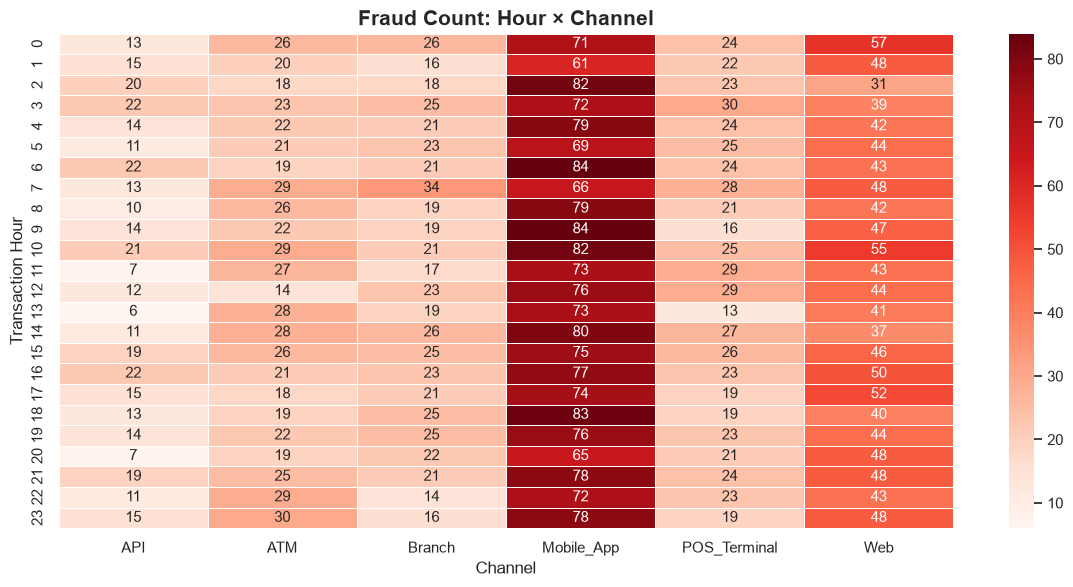

In [45]:
# Fraud Heatmap: Hour × Channel
fraud_heatmap = (df[df['is_fraud']==1]
                   .groupby(['transaction_hour','channel'])
                   .size().unstack(fill_value=0))
plt.figure(figsize=(12, 6))
sns.heatmap(fraud_heatmap, annot=True, fmt='d', cmap='Reds', linewidths=0.5)
plt.title('Fraud Count: Hour × Channel', fontsize=15, fontweight='bold')
plt.xlabel('Channel')
plt.ylabel('Transaction Hour')
plt.tight_layout()
plt.show()

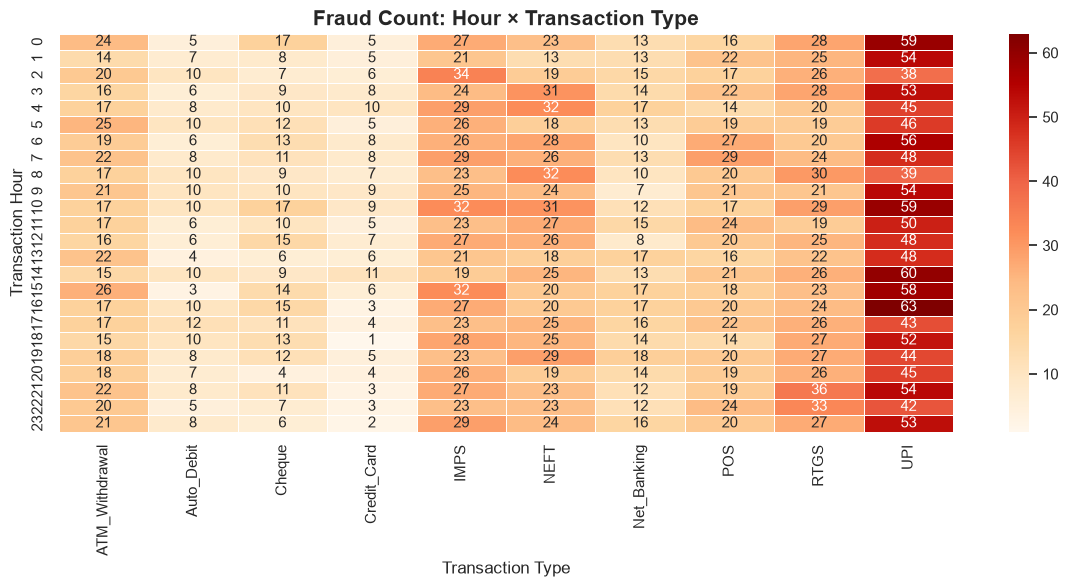

In [46]:
# Fraud Heatmap: Hour × Transaction Type
fraud_type_heatmap = (df[df['is_fraud']==1]
                        .groupby(['transaction_hour','transaction_type'])
                        .size().unstack(fill_value=0))
plt.figure(figsize=(12, 6))
sns.heatmap(fraud_type_heatmap, annot=True, fmt='d', cmap='OrRd', linewidths=0.5)
plt.title('Fraud Count: Hour × Transaction Type', fontsize=15, fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Hour')
plt.tight_layout()
plt.show()

### Key Findings from Fraud analysis: 

| Dimension | Finding |
|---|---|
| Overall Fraud Rate | `0.89`% of all transactions are fraudulent |
| Highest-risk Transaction Type | `RTGS` with `1.85`% fraud rate |
| Highest-risk Channel | `Branch` with `0.95`% fraud rate |
| Peak Fraud Hour | `10 AM`- elevated fraud RATE of `1.01%`|
| Top Fraud State | `Uttar Pradesh` with a fraud rate of 0.95% (followed by West Bengal and Karnataka)|
| Top Fraud Merchant Category | `Peer Transfer` with `0.93%` |
| Amount: Fraudulent vs Genuine | Median fraudulent amount is ₹`2692` vs ₹`2031` genuine |
| Credit Score: Fraudulent vs Genuine | Fraudulent transactions show similar (`600` for both fraudulent and genuine transactions)|

**Hypothesis Results:**
- H1 (fraud varies by type/channel): `Confirmed`- Fraud rates differ across transaction types and channels. RTGS has the highest fraud rate among transaction types `(1.85%)`, while Branch records the highest channel-level fraud rate `(0.95%)`.
- H2 (night hours show elevated fraud rate): `Rejected`- Based on the fraud rate analysis, the peak fraud rate occurs at `10 AM (1.01%)`, not during late-night hours. RTGS transactions (`Peer Transfer- 0.93%`) are primarily processed during banking hours, which explains why fraud peaks at 10 AM rather than late night.
- H3 (merchant category risk concentration): `Confirmed`- Fraud is concentrated in specific merchant categories, with some categories exhibiting noticeably higher fraud rates than others.
- H4 (state-level clustering): `Confirmed`- Fraud rates vary across states. `Uttar Pradesh, West Bengal, and Karnataka` emerge as the highest-risk states in this dataset.
- H5 (distinct distributions in amount/score): `Partially Confirmed`- Fraudulent transactions have a higher median transaction amount `(₹2,692 vs ₹2,031)`, but the median credit score remains identical (600) for both fraudulent and genuine transactions.

## Correlation & Multivariate Analysis
Exploring relationships between numerical features to identify patterns relevant to fraud detection.

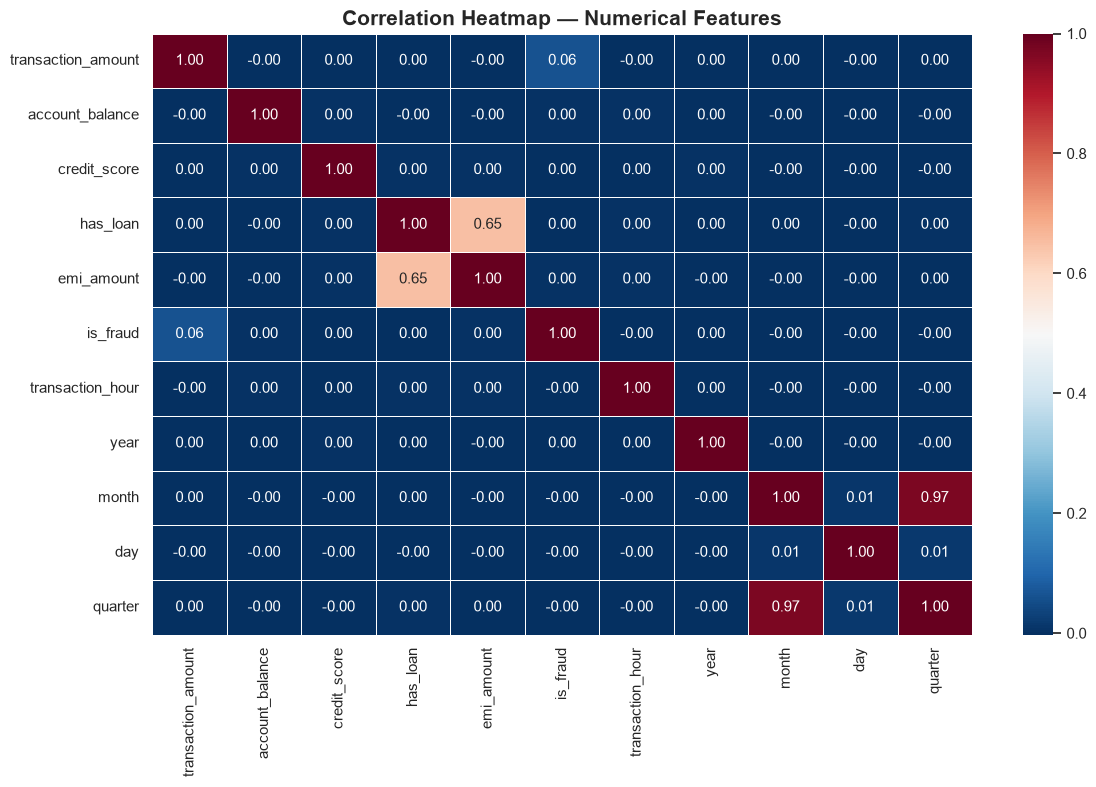

Feature correlations with is_fraud:
transaction_amount    0.060638
quarter              -0.002466
month                -0.002457
account_balance       0.001734
emi_amount            0.001489
has_loan              0.000949
day                  -0.000634
transaction_hour     -0.000264
year                  0.000230
credit_score          0.000186


In [47]:
# Correlation Matrix
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="RdBu_r", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap — Numerical Features", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Print top correlations with is_fraud
fraud_corr = corr['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False)
print("Feature correlations with is_fraud:")
print(fraud_corr.to_string())

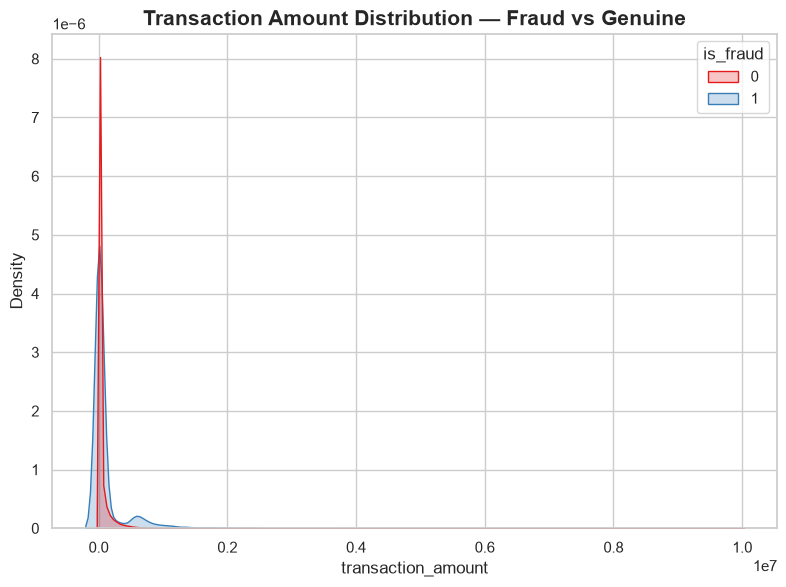

In [48]:
# KDE: Transaction Amount by Fraud Status
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x="transaction_amount", hue="is_fraud",
            fill=True, common_norm=False, palette="Set1")
plt.title("Transaction Amount Distribution — Fraud vs Genuine",
          fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

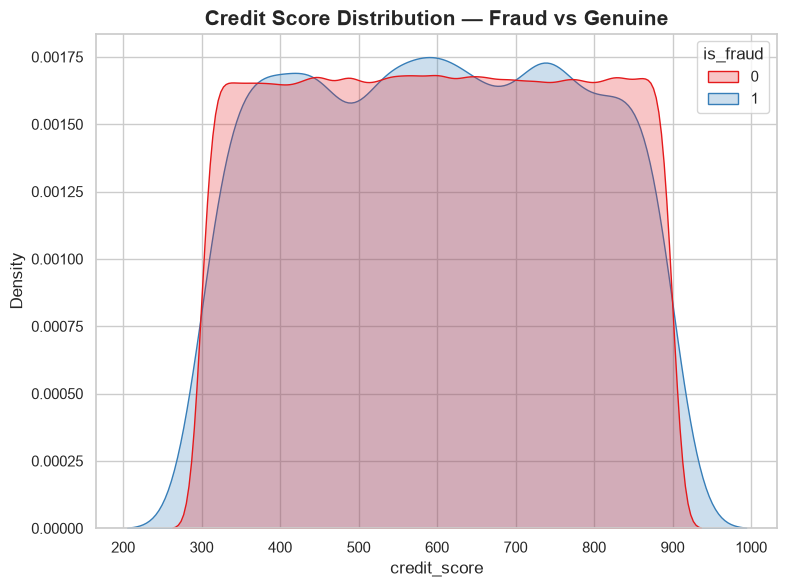

In [49]:
# KDE: Credit Score by Fraud Status
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x="credit_score", hue="is_fraud",
            fill=True, common_norm=False, palette="Set1")
plt.title("Credit Score Distribution — Fraud vs Genuine",
          fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Observation

- The correlation analysis indicates that **`is_fraud` has only weak linear relationships with the numerical features**, suggesting that fraud cannot be explained by a single numeric variable alone.

- **Transaction amount shows a slightly stronger association with fraudulent transactions** than other numerical features, whereas **credit score exhibits minimal separation** between genuine and fraudulent transactions.

- The KDE distributions show substantial overlap between fraudulent and genuine transactions, indicating that **fraud detection is a complex classification problem**. Effective fraud detection is therefore likely to benefit from combining numerical variables with categorical features (such as transaction type, channel, merchant category, and state) rather than relying on individual numerical attributes.

## EDA Conclusion

This analysis examined **550,000 banking transactions** across Indian customers to understand transaction behaviour, identify fraud patterns, and derive actionable business insights.

### Transaction Behaviour

- The dataset includes multiple transaction types, with **UPI** accounting for the largest share of transactions.
- Digital banking channels process the majority of transactions, while branch-based transactions exhibit relatively higher fraud risk.
- Transaction activity varies throughout the day, with distinct peak transaction hours.

### Fraud Patterns

- The overall fraud rate is **0.89%**, indicating a highly imbalanced dataset where genuine transactions significantly outnumber fraudulent ones.
- **RTGS** records the highest fraud rate among transaction types, while **Branch** is the highest-risk transaction channel.
- Fraud activity reaches its highest rate around **10 AM**, suggesting that fraud risk depends on transaction timing rather than simply transaction volume.
- **Uttar Pradesh** exhibits the highest state-level fraud rate. Fraud is also concentrated in specific merchant categories, indicating category-specific risk.

### Business Recommendations

| Priority | Recommendation | Rationale |
|----------|----------------|-----------|
| High | Implement additional verification for high-risk transaction types such as **RTGS**, particularly when processed through **Branch** channels. | These combinations exhibit the highest observed fraud rates. |
| High | Introduce real-time fraud monitoring during peak fraud hours, especially around **10 AM**. | Fraud risk varies by transaction time and increases during specific hours. |
| Medium | Continuously monitor high-risk states such as **Uttar Pradesh** and other states with elevated fraud rates. | Geographic concentration may indicate localized fraud patterns requiring additional monitoring. |
| Medium | Strengthen monitoring for merchant categories with elevated fraud rates. | Merchant-specific fraud patterns may indicate compromised merchants or higher-risk business segments. |
| Low | Use transaction amount, transaction type, channel, transaction hour, and merchant category together when developing fraud detection models. | Individual numerical variables show weak relationships with fraud, making multi-feature analysis more effective. |


### Next Steps

- Perform feature engineering for fraud detection.
- Build a baseline **Logistic Regression** model.
- Evaluate tree-based models such as **Random Forest** and **XGBoost**.
- Address class imbalance using techniques such as **SMOTE** or **class weighting**.
